<a href="https://colab.research.google.com/github/pranjalx07/prompt-injection-detection/blob/main/1_shap_lime_insertion_deletion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = "/content/drive/MyDrive/optimized model 4th august (old)"

import os
print(os.listdir(SAVE_DIR))  # sanity check — should list config.json, model.safetensors, etc.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['config.json', 'model.safetensors', 'training_args.bin', 'tokenizer_config.json', 'tokenizer.json', '50ktrain.ipynb']


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(SAVE_DIR)
model = AutoModelForSequenceClassification.from_pretrained(SAVE_DIR).to(device)
model.eval()
print("Loaded successfully on:", device)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded successfully on: cuda


In [ ]:

import re

def clean_text(t: str) -> str:
    t = str(t).lower()
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"\s+", " ", t)
    t = re.sub(r"([!?.,])\1{1,}", r"\1", t)
    return t.strip()

In [ ]:
# ==========================================================================
# Rebuild test_df_eval WITHOUT retraining — just reload data + run inference
# ==========================================================================

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# ---- EDIT THIS ----
DATA_PATH = "/content/drive/MyDrive/preprocessed_prompt_injection_dataset_no_dataset1_balanced.csv"
# -------------------

MAX_LEN = 256
SEED = 42
BATCH_SIZE = 32  # safe batch size for inference, won't run out of memory

# ---------------------------------------------------------------------
# 1. Load and clean data (same steps as training notebook)
# ---------------------------------------------------------------------
df = pd.read_csv(DATA_PATH)
assert "text" in df.columns and "label" in df.columns, "CSV must have 'text' and 'label' columns"

has_source = "source" in df.columns
if not has_source:
    df["source"] = "unknown"

df = df.dropna(subset=["text", "label"]).drop_duplicates(subset=["text"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)
df["text"] = df["text"].apply(clean_text)   # uses clean_text() you already pasted
df = df[df["text"].str.len() > 0].reset_index(drop=True)

print("Full cleaned dataset:", df.shape)

# ---------------------------------------------------------------------
# 2. Reproduce the EXACT same train/val/test split (same seed = same split)
# ---------------------------------------------------------------------
df["strat_key"] = df["label"].astype(str) + "__" + df["source"].astype(str)
counts = df["strat_key"].value_counts()
valid_keys = counts[counts >= 3].index
df = df[df["strat_key"].isin(valid_keys)].reset_index(drop=True)

test_size = 0.15
val_size = 0.15

train_val_df, test_df = train_test_split(
    df, test_size=test_size, stratify=df["strat_key"], random_state=SEED
)
# (we don't need the train/val split itself here, just need test_df to match exactly)

test_df = test_df.drop(columns=["strat_key"]).reset_index(drop=True)
print("Test set:", test_df.shape)

# ---------------------------------------------------------------------
# 3. Run inference in batches (fast — this is NOT training)
# ---------------------------------------------------------------------
model.eval()
all_preds = []
all_probs = []

texts = test_df["text"].tolist()

with torch.no_grad():
    for i in range(0, len(texts), BATCH_SIZE):
        batch_texts = texts[i:i + BATCH_SIZE]
        inputs = tokenizer(
            batch_texts, truncation=True, padding=True,
            max_length=MAX_LEN, return_tensors="pt"
        ).to(device)

        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        preds = np.argmax(probs, axis=-1)

        all_preds.extend(preds.tolist())
        all_probs.extend(probs.tolist())

        if i % (BATCH_SIZE * 10) == 0:
            print(f"  Processed {i}/{len(texts)}", end="\r")

print(f"\nDone. Processed {len(all_preds)} test examples.")

# ---------------------------------------------------------------------
# 4. Build test_df_eval — same structure the faithfulness script expects
# ---------------------------------------------------------------------
test_df_eval = test_df.copy()
test_df_eval["pred"] = all_preds
test_df_eval["true"] = test_df_eval["label"]

acc = accuracy_score(test_df_eval["true"], test_df_eval["pred"])
p, r, f1, _ = precision_recall_fscore_support(
    test_df_eval["true"], test_df_eval["pred"], average="binary"
)
print(f"\nSanity check — Test Accuracy: {acc:.4f} | Precision: {p:.4f} | Recall: {r:.4f} | F1: {f1:.4f}")
print("(These numbers should roughly match what you saw in Section 10 of the training notebook)")

print("\ntest_df_eval is ready. You can now run the faithfulness evaluation script.")

Full cleaned dataset: (50689, 5)
Test set: (7604, 5)

Done. Processed 7604 test examples.

Sanity check — Test Accuracy: 0.9780 | Precision: 0.9843 | Recall: 0.9716 | F1: 0.9779
(These numbers should roughly match what you saw in Section 10 of the training notebook)

test_df_eval is ready. You can now run the faithfulness evaluation script.


In [ ]:
!pip install -q shap lime

Pulled 20 correctly-classified malicious prompts for evaluation.
Example: run: _ `bash -c 'whoami | xxd -p'`

Running SHAP faithfulness evaluation...
  [SHAP] 20/20
Running LIME faithfulness evaluation...
  [LIME] 20/20


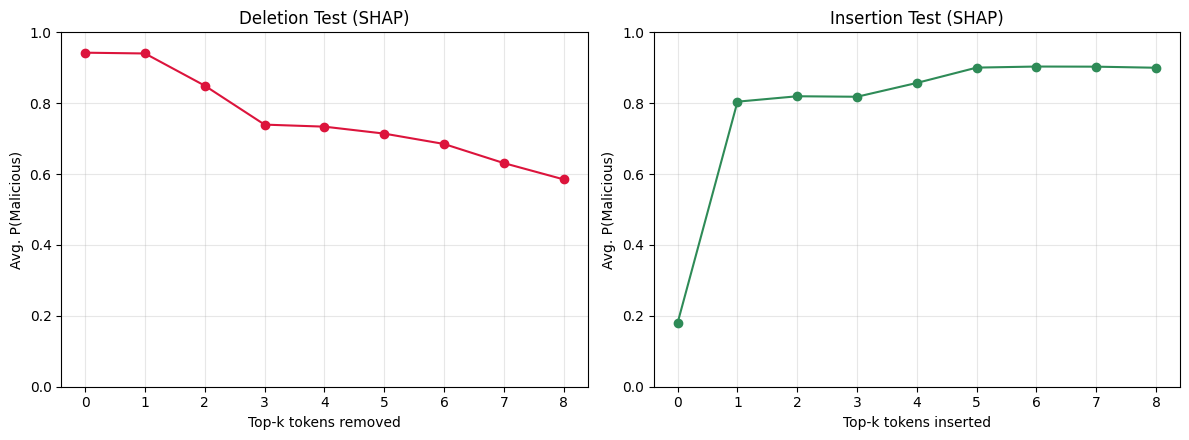

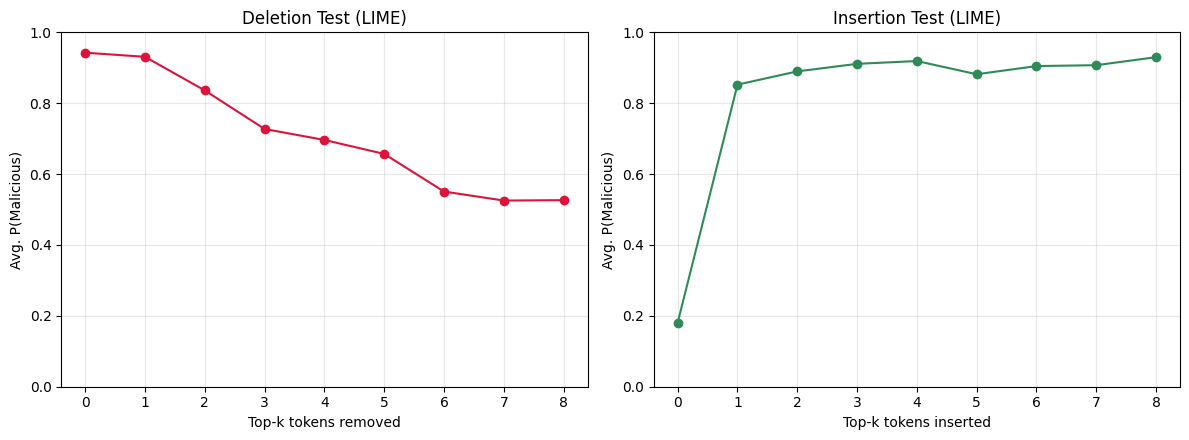


=== Faithfulness Summary ===
Method  Comprehensiveness (prob drop)  Sufficiency (prob recovered)
  SHAP                       0.357452                      0.719034
  LIME                       0.416129                      0.748883

Higher values for both metrics = more faithful explanations.

Saved: faithfulness_summary.csv, faithfulness_shap.png, faithfulness_lime.png


In [ ]:
# ==========================================================================
# FAITHFULNESS EVALUATION — SHAP & LIME on the fine-tuned DistilBERT model
# ==========================================================================
import numpy as np
import pandas as pd
import torch
import shap
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt

MAX_LEN = CONFIG["max_length"]

# ---------------------------------------------------------------------
# 1. Prediction function (matches predict_prompt from Section 12)
# ---------------------------------------------------------------------

def predict_proba(texts, batch_size=32):
    """Returns array of shape (n, 2): [P(Safe), P(Malicious)] for each text.
    Batches internally so LIME's large perturbation sets (~5000 per call)
    don't blow up GPU memory in one shot."""
    if isinstance(texts, str):
        texts = [texts]
    model.eval()
    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            cleaned = [clean_text(t) for t in batch]
            inputs = tokenizer(cleaned, truncation=True, padding=True,
                                max_length=MAX_LEN, return_tensors="pt").to(device)
            logits = model(**inputs).logits
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
            del inputs, logits
        torch.cuda.empty_cache()
    return np.concatenate(all_probs, axis=0)


def predict_malicious_prob(text):
    if not text.strip():
        return predict_proba(" ")[0][1]  # neutral single-space input, not a special marker string
    return predict_proba(text)[0][1]


# ---------------------------------------------------------------------
# 2. Pull correctly-classified malicious prompts from your test set
#    (reuses test_df_eval already built in Section 11 of the training notebook)
# ---------------------------------------------------------------------

def get_sample_prompts(n=20, seed=42):
    """
    Pulls n malicious prompts that the model correctly classified
    (true=1, pred=1) from test_df_eval, so faithfulness testing runs
    on examples we know the model actually 'gets right'.
    """
    correct_malicious = test_df_eval[
        (test_df_eval["true"] == 1) & (test_df_eval["pred"] == 1)
    ]
    sample = correct_malicious.sample(n=min(n, len(correct_malicious)), random_state=seed)
    return sample["text"].tolist()


SAMPLE_PROMPTS = get_sample_prompts(n=20)
print(f"Pulled {len(SAMPLE_PROMPTS)} correctly-classified malicious prompts for evaluation.")
print("Example:", SAMPLE_PROMPTS[0])


# ---------------------------------------------------------------------
# 3. Token importance rankings — SHAP and LIME
# ---------------------------------------------------------------------

_shap_explainer = shap.Explainer(predict_proba, shap.maskers.Text())
_lime_explainer = LimeTextExplainer(class_names=["Safe", "Malicious"])


def get_shap_ranking(text):
    sv = _shap_explainer([text])
    tokens = sv.data[0]
    values = sv.values[0][:, 1]  # class 1 = Malicious
    ranked = sorted(zip(tokens, values), key=lambda x: -abs(x[1]))
    return [t for t, v in ranked if t.strip()]


def get_lime_ranking(text, num_features=20):
    exp = _lime_explainer.explain_instance(
        text, predict_proba, num_features=num_features, labels=(1,),
        num_samples=500  # reduced from LIME's default 5000 — still stable, much faster/lighter
    )
    weighted = exp.as_list(label=1)
    ranked = sorted(weighted, key=lambda x: -abs(x[1]))
    return [t for t, w in ranked]


# ---------------------------------------------------------------------
# 4. Deletion and insertion tests
# ---------------------------------------------------------------------

def deletion_test(text, ranking, max_k=8):
    """
    Removes top-k important tokens from the text. Matching is done
    case-insensitively and strips leading/trailing punctuation/whitespace,
    since SHAP/LIME can return subword pieces or tokens with attached
    punctuation that won't exact-match a plain text.split().
    """
    words = text.split()

    def normalize(w):
        return w.strip().strip(".,!?;:\"'()[]{}").lower()

    results = [(0, predict_malicious_prob(text))]
    removed_norm = set()
    for k in range(1, max_k + 1):
        if k - 1 >= len(ranking):
            break
        removed_norm.add(normalize(ranking[k - 1]))
        remaining = [w for w in words if normalize(w) not in removed_norm]
        modified = " ".join(remaining) if remaining else ""
        results.append((k, predict_malicious_prob(modified)))
    return results


def insertion_test(text, ranking, max_k=8):
    """
    Starts from a neutral baseline (empty string) and inserts top-k
    important tokens one at a time.
    """
    results = [(0, predict_malicious_prob(""))]
    inserted = []
    for k in range(1, max_k + 1):
        if k - 1 >= len(ranking):
            break
        inserted.append(ranking[k - 1].strip())
        partial = " ".join(inserted)
        results.append((k, predict_malicious_prob(partial)))
    return results


# ---------------------------------------------------------------------
# 5. Run across all sample prompts, average curves
# ---------------------------------------------------------------------

def run_faithfulness(prompts, method="shap", max_k=8):
    del_curves, ins_curves = [], []
    for i, text in enumerate(prompts):
        print(f"  [{method.upper()}] {i+1}/{len(prompts)}", end="\r")
        ranking = get_shap_ranking(text) if method == "shap" else get_lime_ranking(text)
        del_curves.append(deletion_test(text, ranking, max_k))
        ins_curves.append(insertion_test(text, ranking, max_k))
    print()

    # Pad curves that stopped early (short prompts with fewer than max_k tokens)
    # by repeating their last value, so every curve has length max_k+1 before averaging.
    target_len = max_k + 1

    def pad_curve(curve):
        probs = [p for _, p in curve]
        if len(probs) < target_len:
            probs = probs + [probs[-1]] * (target_len - len(probs))
        return probs[:target_len]

    del_matrix = [pad_curve(c) for c in del_curves]
    ins_matrix = [pad_curve(c) for c in ins_curves]

    avg_del = np.mean(del_matrix, axis=0)
    avg_ins = np.mean(ins_matrix, axis=0)
    return avg_del, avg_ins


print("\nRunning SHAP faithfulness evaluation...")
shap_del, shap_ins = run_faithfulness(SAMPLE_PROMPTS, method="shap", max_k=8)

print("Running LIME faithfulness evaluation...")
lime_del, lime_ins = run_faithfulness(SAMPLE_PROMPTS, method="lime", max_k=8)


# ---------------------------------------------------------------------
# 6. Plot and report
# ---------------------------------------------------------------------

def plot_curves(avg_del, avg_ins, method_name):
    k_vals = list(range(len(avg_del)))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    axes[0].plot(k_vals, avg_del, marker='o', color='crimson')
    axes[0].set_title(f"Deletion Test ({method_name})")
    axes[0].set_xlabel("Top-k tokens removed")
    axes[0].set_ylabel("Avg. P(Malicious)")
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)

    axes[1].plot(k_vals, avg_ins, marker='o', color='seagreen')
    axes[1].set_title(f"Insertion Test ({method_name})")
    axes[1].set_xlabel("Top-k tokens inserted")
    axes[1].set_ylabel("Avg. P(Malicious)")
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"/content/faithfulness_{method_name.lower()}.png", dpi=150)
    plt.show()


plot_curves(shap_del, shap_ins, "SHAP")
plot_curves(lime_del, lime_ins, "LIME")

shap_comp = shap_del[0] - shap_del[-1]
shap_suff = shap_ins[-1] - shap_ins[0]
lime_comp = lime_del[0] - lime_del[-1]
lime_suff = lime_ins[-1] - lime_ins[0]

summary = pd.DataFrame({
    "Method": ["SHAP", "LIME"],
    "Comprehensiveness (prob drop)": [shap_comp, lime_comp],
    "Sufficiency (prob recovered)": [shap_suff, lime_suff],
})
print("\n=== Faithfulness Summary ===")
print(summary.to_string(index=False))
print("\nHigher values for both metrics = more faithful explanations.")

summary.to_csv("/content/faithfulness_summary.csv", index=False)
print("\nSaved: faithfulness_summary.csv, faithfulness_shap.png, faithfulness_lime.png")

In [ ]:
from google.colab import files
files.download('/content/faithfulness_lime.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('/content/faithfulness_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>